# Домашнее задание: Кластеризация текстов

Сеть супермаркетов «Перекрёсток» собирает отзывы от клиентов по разным каналам: мобильное приложение, сайт, чековые анкеты. Отзывы включают как положительные оценки, так и жалобы — на персонал, доставку, свежесть товаров, наличие и т.д.

**Бизнес сталкивается с проблемой**:

* Отзывов слишком много, они разнообразны по формулировкам.
* Ручная обработка отзывов — долгая и неэффективная.
* Нельзя быстро понять, о чём говорят клиенты, какие темы повторяются.

**Цель бизнеса**:

* Автоматически группировать отзывы по смыслу, чтобы:
* обнаруживать повторяющиеся проблемы (например, "не тот товар", "просрочка"),
* оценивать работу конкретных магазинов и доставок,
* поддерживать продуктовые и операционные улучшения на основе обратной связи.



In [1]:
!pip freeze > start_env.txt

# Читаем данные

Скачаем данные по отзывам на продукты. Предобработаем их и отфильтруем небольшое количество, чтобы потрогать руками различные алгоритмы, рассмотренные на лекции.

Для упрощения анализа кластеров и возможности здраво оценить, насколько результаты приемлемы, разделим данные на две явно разделенные по смыслу (во всяком случае, в среднем) группы: отзывы с максимальной оценкой и отзывы с минимальной оценкой.

In [2]:
# # помогает с ошибкой чтения датасета с HF
# !pip install fsspec==2023.6.0

In [3]:
import logging


logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(name)s - %(levelname)s - %(message)s", force=True)
logger = logging.getLogger(__name__)

In [4]:
from datasets import load_dataset

# Загружаем train-часть датасета
dataset = load_dataset("lapki/perekrestok-reviews", split="train")
print(dataset)

2026-04-21 12:26:50,117 - numexpr.utils - INFO - NumExpr defaulting to 2 threads.
2026-04-21 12:26:50,918 - datasets - INFO - TensorFlow version 2.19.0 available.
2026-04-21 12:26:50,921 - datasets - INFO - JAX version 0.7.2 available.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(
2026-04-21 12:27:02,113 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/datasets/lapki/perekrestok-reviews/resolve/main/README.md "HTTP/1.1 307 Temporary Redirect"
2026-04-21 12:27:02,216 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/datasets/lapki/

README.md:   0%|          | 0.00/709 [00:00<?, ?B/s]

2026-04-21 12:27:02,448 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/datasets/lapki/perekrestok-reviews/resolve/6579085ad399e03b9f39273a57a79affa299b9c6/perekrestok-reviews.py "HTTP/1.1 404 Not Found"
2026-04-21 12:27:02,449 - huggingface_hub.utils._http - WARNING - Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
2026-04-21 12:27:02,665 - httpx - INFO - HTTP Request: HEAD https://s3.amazonaws.com/datasets.huggingface.co/datasets/datasets/lapki/perekrestok-reviews/lapki/perekrestok-reviews.py "HTTP/1.1 404 Not Found"
2026-04-21 12:27:02,765 - httpx - INFO - HTTP Request: GET https://huggingface.co/api/datasets/lapki/perekrestok-reviews/revision/6579085ad399e03b9f39273a57a79affa299b9c6 "HTTP/1.1 200 OK"
2026-04-21 12:27:02,860 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/datasets/lapki/perekrestok-reviews/resolve/6579085ad399e03b9f39273a57a79affa299b9c6/.huggingface.yaml 

perekrestok.jsonl:   0%|          | 0.00/606M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/642682 [00:00<?, ? examples/s]

Dataset({
    features: ['product_id', 'product_name', 'product_category', 'product_price', 'review_id', 'review_author', 'review_text', 'rating'],
    num_rows: 642682
})


In [5]:
from datasets import load_dataset
import pandas as pd

N = 10000
df = dataset.to_pandas()
df = df[["review_id", "product_category", "product_name", "review_text", "rating"]]
df = df.sort_values(by="review_id").head(N)
df.head(2)


,review_id,product_category,product_name,review_text,rating
128218,1493,Для мам и детей,Сок Сады Придонья Яблоко зеленое 125мл,Самые лучшие соки. Всегда беру детям только их...,5.0
426797,1496,Сладости,Пастила Белевская Пастильная Мануфактура Класс...,"Вкуснее, чем у известных конкурентов.",5.0


In [6]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Применяем очистку
df["clean_text"] = df["review_text"].apply(clean_text)
df.head(2)

,review_id,product_category,product_name,review_text,rating,clean_text
128218,1493,Для мам и детей,Сок Сады Придонья Яблоко зеленое 125мл,Самые лучшие соки. Всегда беру детям только их...,5.0,самые лучшие соки. всегда беру детям только их...
426797,1496,Сладости,Пастила Белевская Пастильная Мануфактура Класс...,"Вкуснее, чем у известных конкурентов.",5.0,"вкуснее, чем у известных конкурентов."


In [7]:
neg = df[df["rating"] == 1.0].sort_values(by="review_id")[:500]
pos = df[df["rating"] == 5.0].sort_values(by="review_id")[:500]
cut_df = pd.concat([neg, pos]).reset_index(drop=True)
cut_df["rating"].value_counts()

,count
rating,
1.0,500
5.0,500


In [8]:
cut_df.head(2)

,review_id,product_category,product_name,review_text,rating,clean_text
0,3972,"Чай, кофе, сахар",Сахар песок белый 1кг,запекала сахар вместе с дыней. дыня совсем не ...,1.0,запекала сахар вместе с дыней. дыня совсем не ...
1,4462,"Чай, кофе, сахар",Кофе молотый Julius Meinl Prasident 250г,Почти без запаха.,1.0,почти без запаха.


# Алгоритмы визуализации - 5 баллов

Реализуйте функции для сжатия эмбеддингов до двумерного пространства с помощью подходов t-SNE и UMAP. Каждая функция должна строить изображения поданных на вход эмбеддингов в пространстве, а также учитывать, какое расстояние между эмбеддингами мы считаем (евклидово или косинусное).

Протестируйте их на небольшом семпле.

In [ ]:
from typing import Any

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
import umap

import seaborn as sns
from numpy.typing import NDArray

SEED = 20260421

# Можно реализовать через одну функцию, но для тестирования разных сетапов было удобно делать две отдельно


def plot_projection(projection: NDArray, title: str, scatter_kws):
    sns.set_style("whitegrid")
    _ = sns.relplot(
        x=projection[:, 0],
        y=projection[:, 1],
        kind="scatter",
        height=4,
        alpha=0.5,
        s=15
        **scatter_kws,
    )
    plt.suptitle(title, y=1.05)
    plt.show()


# Визуализация через t-SNE
def plot_embeddings(
    embeds,
    title,
    metric="euclidean",
    random_state: int = SEED,
    reducer_kws: dict[str, Any] | None = None,
    scatter_kws: dict[str, Any] | None = None,
):
    reducer = TSNE(metric=metric, random_state=random_state, **(reducer_kws or {}))
    projection = reducer.fit_transform(X=embeds)
    plot_projection(projection, title, scatter_kws or {})


# Визуализация через UMAP
def plot_embeddings_umap(
    embeds,
    title,
    metric="euclidean",
    random_state: int = SEED,
    reducer_kws: dict[str, Any] | None = None,
    scatter_kws: dict[str, Any] | None = None,
):
    reducer = umap.UMAP(metric=metric, random_state=random_state, **(reducer_kws or {}))
    projection = reducer.fit_transform(X=embeds)
    plot_projection(projection, title, scatter_kws or {})

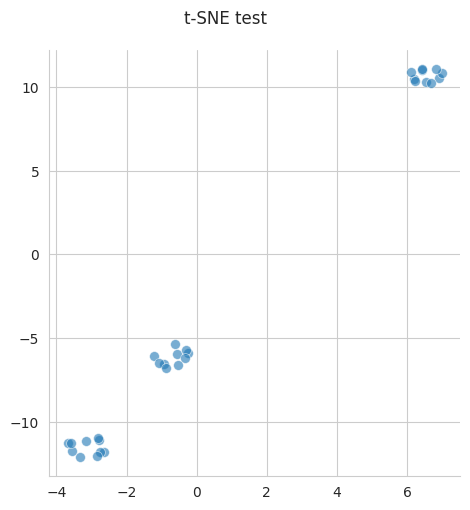

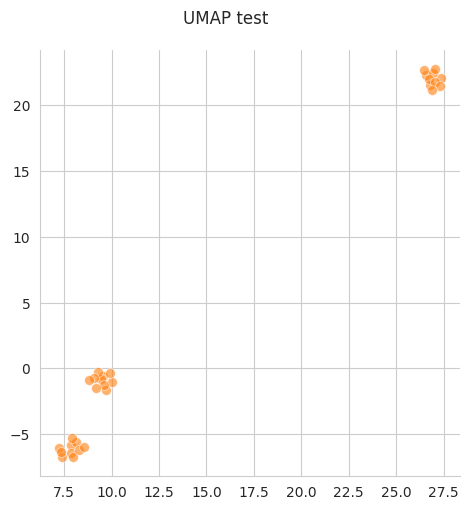

In [10]:
np.random.seed(SEED)

embs = np.concatenate([np.random.rand(10, 3), np.random.rand(10, 3) + 2, np.random.rand(10, 3) - 1], axis=0)

plot_embeddings(embs, "t-SNE test", metric="euclidean", reducer_kws={"perplexity": 10})
plot_embeddings_umap(embs, "UMAP test", metric="euclidean", reducer_kws={"n_jobs": 1}, scatter_kws={"color": "C1"})

# Зависимость кластеров от эмбеддера - 5 баллов

В данной части предлагается оценить, насколько эмбеддер на качество кластеризации может влиять:
а) эмбеддер
б) выбранная метрика расстояния

Возьмите следующие две модели:
1) "ai-forever/FRIDA" -- хороший качественный эмбеддер
2) "cointegrated/rubert-tiny2" -- достаточно слабый по современным меркам эмбеддер

Реализуйте подгрузку этой модели через класс SentenceTransformer и постройте визуализацию кластеров
а) через функцию с UMAP и через функцию с t-SNE
б) и для каждого варианта -- визуализацию с евклидовым расстоянием и с косинусным расстоянием
в) и для каждого варианта -- с эмбеддером FRIDA и с эмбеддером rubert-tiny2

Итого должно получиться 8 графиков. Сделайте выводы, какой эмбеддер визуально разграничивает данные лучше.

2026-04-21 13:09:33,104 - __main__ - INFO - Device: cuda


Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


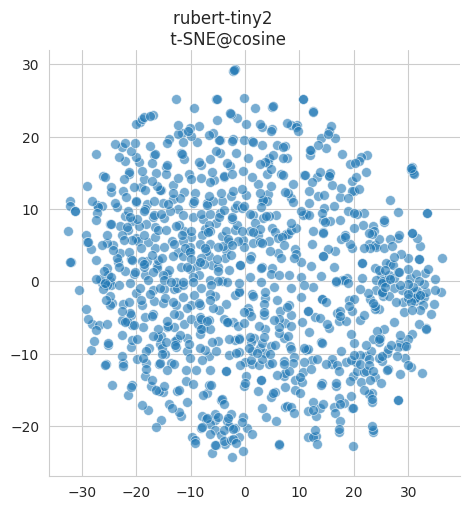

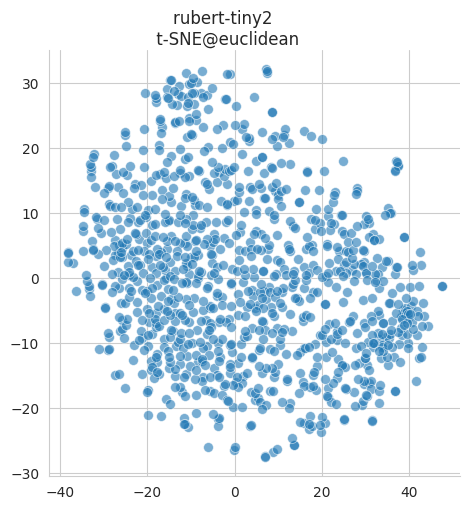

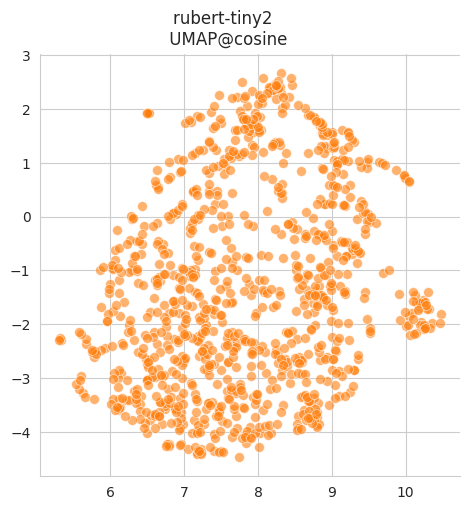

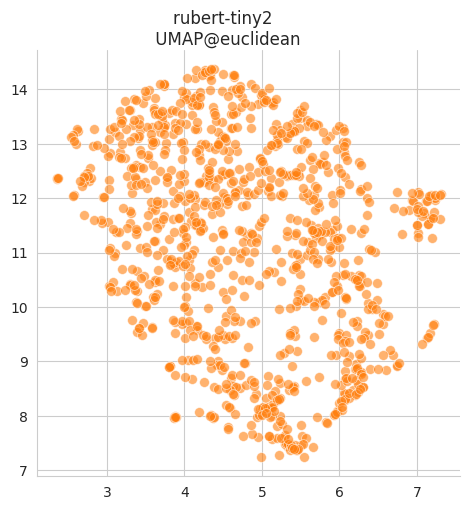

Loading weights:   0%|          | 0/219 [00:00<?, ?it/s]

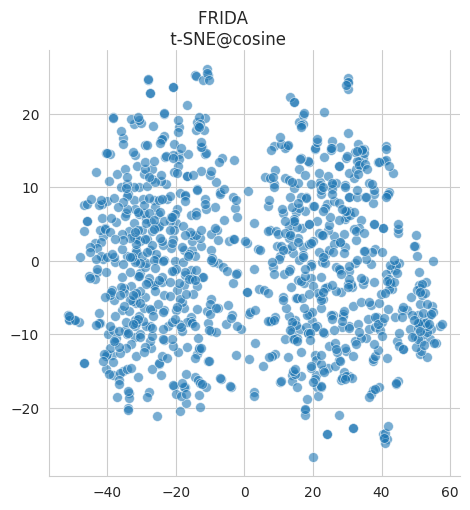

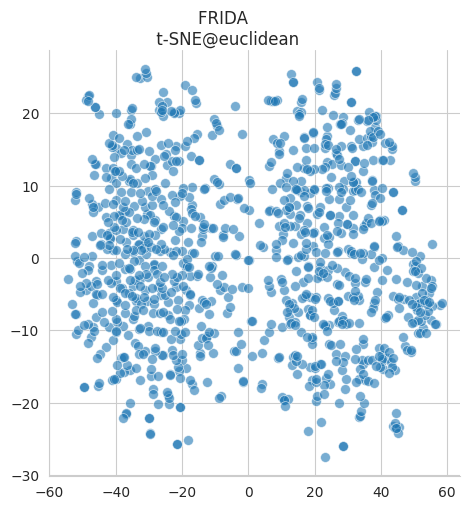

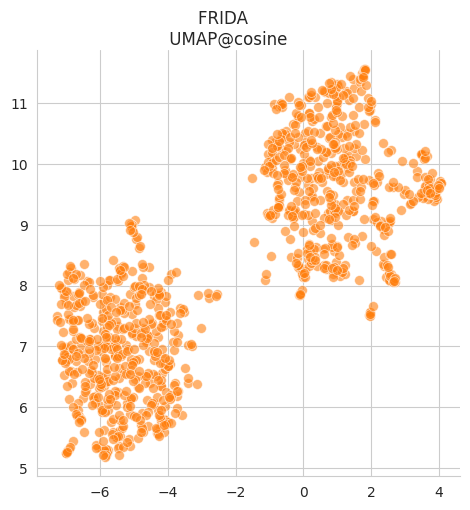

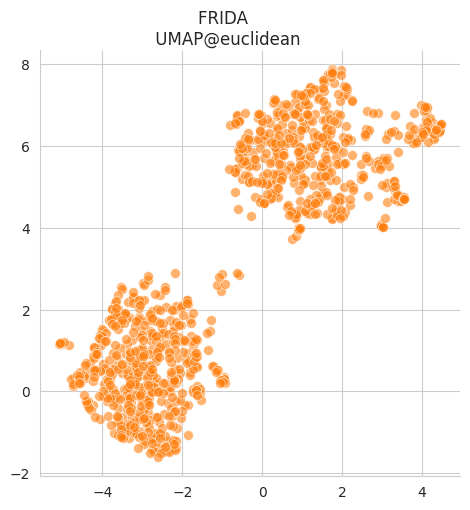

In [23]:
from sentence_transformers import SentenceTransformer
import torch


logging.getLogger("httpx").setLevel(logging.WARNING)
logging.getLogger("sentence_transformers").setLevel(logging.WARNING)


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
logger.info(f"Device: {DEVICE}")

texts = cut_df["clean_text"].values.tolist()


# ---- Ваш код здесь ----
def get_embeddings(
    model: SentenceTransformer,
    texts: list[str] = texts,
) -> NDArray:
    embs: NDArray = model.encode(
        texts,
        output_value="sentence_embedding",
        convert_to_numpy=True,
        normalize_embeddings=True,
        show_progress_bar=False,
        chunk_size=16,
        batch_size=16,
    )
    return embs


# Rubert
model_rubert = SentenceTransformer("cointegrated/rubert-tiny2", device=DEVICE)
embs_rubert = get_embeddings(model_rubert)
plot_embeddings(
    embs_rubert,
    title="rubert-tiny2 \n t-SNE@cosine",
    metric="cosine",
)
plot_embeddings(
    embs_rubert,
    title="rubert-tiny2 \n t-SNE@euclidean",
    metric="euclidean",
)
plot_embeddings_umap(
    embs_rubert,
    title="rubert-tiny2 \n UMAP@cosine",
    metric="cosine",
    reducer_kws={"min_dist": 0, "densmap": True, "dens_lambda": 0.05, "n_jobs": 1},
    scatter_kws={"color": "C1"},
)
plot_embeddings_umap(
    embs_rubert,
    title="rubert-tiny2 \n UMAP@euclidean",
    metric="euclidean",
    reducer_kws={"min_dist": 0, "densmap": True, "dens_lambda": 0.05, "n_jobs": 1},
    scatter_kws={"color": "C1"},
)


# FRIDA
model_frida = SentenceTransformer("ai-forever/FRIDA", device=DEVICE)
embs_frida = get_embeddings(model_frida)
plot_embeddings(
    embs_frida,
    title="FRIDA \n t-SNE@cosine",
    metric="cosine",
)
plot_embeddings(
    embs_frida,
    title="FRIDA \n t-SNE@euclidean",
    metric="euclidean",
)
plot_embeddings_umap(
    embs_frida,
    title="FRIDA \n UMAP@cosine",
    metric="cosine",
    reducer_kws={"n_jobs": 1},
    scatter_kws={"color": "C1"},
)
plot_embeddings_umap(
    embs_frida,
    title="FRIDA \n UMAP@euclidean",
    metric="euclidean",
    reducer_kws={"n_jobs": 1},
    scatter_kws={"color": "C1"},
)


Эмбеддинги, полученные с помощью FRIDA, показали хорошую разделимость уже при параметрах по умолчанию, особенно на UMAP. В то время как убедительной видимой разделимости на RUBERT-TINY не удалось добиться даже с с достаточно агрессивным побором параметров.

# Зависимость кластеров от алгоритма кластеризации - 10 баллов

Реализуйте кластеризацию выбранных нами текстов через алгоритмы KMeans, MiniBatchKMeans, HDBSCAN. Сравните эти алгоритмов визуально и по метрикам. В качестве метрик используйте silhouette_score для безотносительной оценки качества и adjusted_rand_score для оценки качества относительно рейтинга (1.0 или 5.0). Визуализацию делайте с помощью UMAP.

compare_clusterers принимает на вход кластеризуемые эмбеддинги и, опционально, референсные значения кластеров (в нашем случае -- принадлежность к рейтингу). Функция должна отрисовывать кластера в пространстве для трех алгоритмов и возвращать метрики по каждому из них в виде словаря.

In [15]:
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.cluster import HDBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score
import umap
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm


def compare_clusterers(embeddings, true_labels=None, n_clusters=5):
    results = {}


    # ---- Ваш код здесь ----
    print("кластеризуем и тремя моделями и считаем метрики силуэт и ari")
    # ---- Конец кода ----

    plt.show()

    return results

In [ ]:
# embeddings: np.array, shape = (n_samples, embedding_dim)
# true_labels: list или np.array (опционально)

true_labels = (cut_df["rating"] == 5.0).apply(int)
results = compare_clusterers(good_embeds, true_labels=None, n_clusters=5)
results

# Интерпретируемость кластеров

## BERTopic - 5 баллов

Попробуем построить интерпретацию получаемых кластеров с помощью BERTopic, реализованного в виде отдельного фреймворка (строит кластера, считает c-TF-IDF, отбирает самые частотные и характеризующие кластер слова).

Если считать частотные слова напрямую, то в топе окажется много служебные слов, которые называют "стоп-словами". Игнорируйте эти слова при построении BERTopic -- это можно сделать с помощью переопределения vectorizer_model, заменив его на sklearn.CountVectorizer с использованием nltk stopwords.

In [16]:
!pip install -q bertopic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.6/150.6 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 43.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 55.9 MB/s eta 0:00:00


In [17]:
from datasets import load_dataset
from sentence_transformers import SentenceTransformer
from bertopic import BERTopic
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from nltk.corpus import stopwords
import nltk

# import plotly.io as pio
# pio.renderers.default = "notebook_connected"

from plotly.io import renderers
renderers.default = "notebook_connected" # интерактив в Jupyter/Colab

In [ ]:

# ---- Ваш код здесь ----
print("стоп-слова и векторайзер")

embedding_model = frida_model
topic_model = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=vectorizer_model,
    language="russian",
    calculate_probabilities=True,
    verbose=False
)

# ---- Конец кода ----

In [ ]:
# ---- Ваш код здесь ----
print("вычисляем топики в каждом кластере, визуализируем / выводим для каждого кластера топовые слова")
# ---- Конец кода ----


df_topics.head()

## Интерпретация через LLM - 15 баллов

Реализуйте интерпретацию кластеров с помощью LLM: кластеризуйте данные с помощью HDBSCAN, удалите аномалии (кластер -1), затем для каждого кластера насемплируйте 5-10 примеров.

Возьмите любую адекватную для русского языка LLM (например, saiga-yandexgpt из первой дз, либо для скорости можно взять qwen-2-0.5b -- хотя по качеству она будет достаточно слабой), и напишите к ней промпт, по которому данная ллм на основе семплированных отзывов должна написать короткое описание кластера.

В качестве результата выведите датафрейм, в котором для каждого кластера будет номер кластера, короткое описание кластера и использованный семпл.

In [ ]:
# чистим cuda память
import gc

torch.cuda.empty_cache()
torch.cuda.empty_cache()
gc.collect()

In [103]:
import pandas as pd
import numpy as np
import random
from sentence_transformers import SentenceTransformer
from sklearn.cluster import HDBSCAN
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from sklearn.metrics.pairwise import cosine_distances
pd.set_option("display.max_colwidth", None)


# ---- Ваш код здесь ----
print("реализуем семлпирование и разметку")
# ---- Конец кода ----

# snorkel / flyingsquid - 10 баллов

В данном разделе предлагается воспользоваться фреймворком для semi-supervised кластеризации, в котором можно определить lf-функции, отображающие некоторые эвристики, и использовать их для автоматической доразметки данных. Необходимо написать как минимум 9 новых правдоподобных правил (то есть суммарно должно быть 10).

В качестве альтернативы допускается использовать flyingsquid (чуть устаревший вариант) -- шаблон кода под него расположен ниже

Для лучшего понимания интерфейса и функциональности предлагается ознакомиться с документацией фреймворков в сети.

In [ ]:
import numpy as np
import pandas as pd
from snorkel.labeling import labeling_function, PandasLFApplier
from snorkel.labeling.model import LabelModel


df = pd.DataFrame({"text": texts})

texts = cut_df["clean_text"].values
# frida_embeds = frida_model.encode(texts, convert_to_numpy=True)
print(len(texts), len(frida_embeds))

df = pd.DataFrame({"text": texts})


ABSTAIN = -1
DELIVERY = 0
QUALITY = 1
SERVICE = 2
PRICE = 3


@labeling_function()
def lf_has_delivery_keywords(series):
    return DELIVERY if any(w in series.text.lower() for w in ["доставка", "курьер", "привезли", "опоздал", "вовремя"]) else ABSTAIN

# ---- Ваш код здесь ----
print("пишем еще 9 функций")
# ---- Конец кода ----



## flyingsquid - если хочется разнообразия 

В качестве альтернативы допускается использовать flyingsquid (чуть устаревший вариант)

Возможно, придется повозиться с установкой зависимостей в зависимости от среды -- ниже приведен необходимый набор установок для среды google colab.

In [1]:
!pip install -q flyingsquid
!pip3 install -q flyingsquid
!pip uninstall -y pgmpy
!pip install pgmpy==0.1.19
!pip3 install pgmpy==0.1.19
!pip install numpy==1.25

In [5]:
import numpy as np
import pandas as pd
from flyingsquid.label_model import LabelModel

texts = cut_df["clean_text"].values
# frida_embeds = frida_model.encode(texts, convert_to_numpy=True)
print(len(texts), len(frida_embeds))

df = pd.DataFrame({"text": texts})


ABSTAIN = -1
DELIVERY = 0
QUALITY = 1
SERVICE = 2
PRICE = 3

def lf_has_delivery_keywords(text):
    return DELIVERY if any(w in text.lower() for w in ["доставка", "курьер", "привезли", "опоздал", "вовремя"]) else ABSTAIN

# ---- Ваш код здесь ----
print("пишем еще 9 функций")
# ---- Конец кода ----




In [6]:
# ---- Ваш код здесь ----
print("запускаем LabelModel.fit() для semi-supervised разметки кластеров и выводим результаты")
# ---- Конец кода ----




=== Кластер -1 ===
- Курьер опоздал на полчаса
- Очень быстрая доставка
- Привезли просроченное молоко
- Упаковка была рваная
- Все доставили вовремя
- Мясо испорчено, неприятный запах
- Курьер не предупредил о приезде
- Фрукты гнилые, явно старые
- Доставка порадовала — быстро и точно
- Сыр с плесенью, ужасный товар


/usr/local/lib/python3.11/dist-packages/pgmpy/models/MarkovModel.py:8: FutureWarning: MarkovModel has been renamed to MarkovNetwork. Please use MarkovNetwork class, MarkovModel will be removed in future.
  warnings.warn(


In [3]:
!pip freeze > end_env.txt